In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

df = pd.read_csv('cleaned_data.csv')

# Konvertera datum
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')

# Skapa revenue-kolumn
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f"Loaded {len(df)} transactions")
print(df.head())

Loaded 397884 transactions
   InvoiceNo StockCode                          Description  Quantity  \
0     536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365     71053                  WHITE METAL LANTERN         6   
2     536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Revenue  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom    15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom    22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34  


In [3]:
# AOV per cusomer
aov_per_customer = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',  # Number of orders
    'Revenue': 'sum'         # Total revenue
}).reset_index()

aov_per_customer.columns = ['CustomerID', 'num_orders', 'total_revenue']
aov_per_customer['avg_order_value'] = aov_per_customer['total_revenue'] / aov_per_customer['num_orders']

print("\nAverage Order Value per customer:")
print(aov_per_customer.head(10))

# Overall AOV
overall_aov = aov_per_customer['avg_order_value'].mean()
print(f"\nOverall Average Order Value: £{overall_aov:.2f}")


Average Order Value per customer:
   CustomerID  num_orders  total_revenue  avg_order_value
0     12346.0           1       77183.60     77183.600000
1     12347.0           7        4310.00       615.714286
2     12348.0           4        1797.24       449.310000
3     12349.0           1        1757.55      1757.550000
4     12350.0           1         334.40       334.400000
5     12352.0           8        2506.04       313.255000
6     12353.0           1          89.00        89.000000
7     12354.0           1        1079.40      1079.400000
8     12355.0           1         459.40       459.400000
9     12356.0           3        2811.43       937.143333

Overall Average Order Value: £419.17


In [4]:
# Purchase frequency 
purchase_frequency = aov_per_customer['num_orders'].mean()
print(f"Average Purchase Frequency: {purchase_frequency:.2f} orders per customer")

# Average days between purchases
customer_purchase_dates = df.groupby('CustomerID')['InvoiceDate'].agg(['min', 'max', 'count']).reset_index()
customer_purchase_dates.columns = ['CustomerID', 'first_purchase', 'last_purchase', 'num_purchases']

# Customer life spans in days
customer_purchase_dates['lifespan_days'] = (customer_purchase_dates['last_purchase'] - customer_purchase_dates['first_purchase']).dt.days

# Average time between purchases
customer_purchase_dates['days_between_purchases'] = customer_purchase_dates['lifespan_days'] / (customer_purchase_dates['num_purchases'] - 1)
customer_purchase_dates['days_between_purchases'] = customer_purchase_dates['days_between_purchases'].replace([np.inf, -np.inf], 0)

avg_days_between = customer_purchase_dates['days_between_purchases'].mean()
print(f"Average days between purchases: {avg_days_between:.1f} days")

Average Purchase Frequency: 4.27 orders per customer
Average days between purchases: 3.3 days


In [5]:
# Average customer lifespan
avg_lifespan_days = customer_purchase_dates['lifespan_days'].mean()
avg_lifespan_months = avg_lifespan_days / 30

print(f"Average Customer Lifespan: {avg_lifespan_days:.1f} days ({avg_lifespan_months:.1f} months)")

# Churn rate
one_time_customers = (customer_purchase_dates['num_purchases'] == 1).sum()
total_customers = len(customer_purchase_dates)
churn_rate = one_time_customers / total_customers

print(f"One-time customers: {one_time_customers} ({churn_rate*100:.1f}%)")
print(f"Repeat customers: {total_customers - one_time_customers} ({(1-churn_rate)*100:.1f}%)")

Average Customer Lifespan: 130.4 days (4.3 months)
One-time customers: 71 (1.6%)
Repeat customers: 4267 (98.4%)


In [6]:
# Metod 1: Enkel CLV (AOV × Purchase Frequency × Lifespan)
clv_data = aov_per_customer.copy()
clv_data = clv_data.merge(customer_purchase_dates[['CustomerID', 'lifespan_days']], on='CustomerID')

# CLV = (Total Revenue / Lifespan) × Expected Lifespan
# Eller enklare: Total Revenue är redan CLV för historical data
clv_data['historical_clv'] = clv_data['total_revenue']

# Predicted CLV baserat på genomsnittliga värden
clv_data['predicted_annual_clv'] = (clv_data['avg_order_value'] * 
                                      (365 / clv_data['lifespan_days'].replace(0, 1)) * 
                                      clv_data['num_orders'])

print("\nCustomer Lifetime Value Analysis:")
print(clv_data.head(10))

# Summering
print(f"\nAverage Historical CLV: £{clv_data['historical_clv'].mean():.2f}")
print(f"Median Historical CLV: £{clv_data['historical_clv'].median():.2f}")
print(f"Total CLV across all customers: £{clv_data['historical_clv'].sum():.2f}")


Customer Lifetime Value Analysis:
   CustomerID  num_orders  total_revenue  avg_order_value  lifespan_days  \
0     12346.0           1       77183.60     77183.600000              0   
1     12347.0           7        4310.00       615.714286            365   
2     12348.0           4        1797.24       449.310000            282   
3     12349.0           1        1757.55      1757.550000              0   
4     12350.0           1         334.40       334.400000              0   
5     12352.0           8        2506.04       313.255000            260   
6     12353.0           1          89.00        89.000000              0   
7     12354.0           1        1079.40      1079.400000              0   
8     12355.0           1         459.40       459.400000              0   
9     12356.0           3        2811.43       937.143333            302   

   historical_clv  predicted_annual_clv  
0        77183.60          2.817201e+07  
1         4310.00          4.310000e+03  
2 

In [7]:
# Bara kunder med mer än 1 order och lifespan > 30 dagar
clv_predicted = clv_data[(clv_data['num_orders'] > 1) & (clv_data['lifespan_days'] > 30)]

print(f"Customers included in predicted CLV: {len(clv_predicted)}")
print(f"Average Predicted Annual CLV: £{clv_predicted['predicted_annual_clv'].mean():.2f}")
print(f"Median Predicted Annual CLV: £{clv_predicted['predicted_annual_clv'].median():.2f}")

Customers included in predicted CLV: 2595
Average Predicted Annual CLV: £5045.55
Median Predicted Annual CLV: £2681.37


In [8]:
# Top 20% customers (Pareto principle)
top_20_pct_threshold = clv_data['historical_clv'].quantile(0.8)

clv_data['customer_tier'] = pd.cut(clv_data['historical_clv'], 
                                     bins=[0, 500, 1000, 2000, 5000, float('inf')],
                                     labels=['Low', 'Medium', 'High', 'Very High', 'VIP'])

print("\nCustomer Tier Distribution:")
print(clv_data['customer_tier'].value_counts())

# Top 10 most valuable customers
top_customers = clv_data.nlargest(10, 'historical_clv')[['CustomerID', 'num_orders', 'avg_order_value', 'total_revenue', 'historical_clv', 'customer_tier']]
print("\nTop 10 High-Value Customers:")
print(top_customers)


Customer Tier Distribution:
customer_tier
Low          1762
Medium        908
High          765
Very High     628
VIP           275
Name: count, dtype: int64

Top 10 High-Value Customers:
      CustomerID  num_orders  avg_order_value  total_revenue  historical_clv  \
1689     14646.0          73      3838.438630      280206.02       280206.02   
4201     18102.0          60      4327.621667      259657.30       259657.30   
3728     17450.0          46      4229.365000      194550.79       194550.79   
3008     16446.0           2     84236.250000      168472.50       168472.50   
1879     14911.0         201       715.547562      143825.06       143825.06   
55       12415.0          21      5948.310952      124914.53       124914.53   
1333     14156.0          55      2134.175091      117379.63       117379.63   
3771     17511.0          31      2937.496129       91062.38        91062.38   
2702     16029.0          63      1286.108571       81024.84        81024.84   
0        12

In [9]:
# Group by tier
tier_summary = clv_data.groupby('customer_tier').agg({
    'CustomerID': 'count',
    'total_revenue': ['sum', 'mean'],
    'num_orders': 'mean',
    'avg_order_value': 'mean'
}).round(2)

tier_summary.columns = ['num_customers', 'total_revenue', 'avg_clv', 'avg_orders', 'avg_order_value']
print("\nCLV Tier Summary:")
print(tier_summary)

# What does top 20% of customers generate¢
top_20_revenue = clv_data.nlargest(int(len(clv_data)*0.2), 'historical_clv')['total_revenue'].sum()
total_revenue = clv_data['total_revenue'].sum()
print(f"\nTop 20% of customers generate: £{top_20_revenue:.2f} ({top_20_revenue/total_revenue*100:.1f}% of total)")


CLV Tier Summary:
               num_customers  total_revenue   avg_clv  avg_orders  \
customer_tier                                                       
Low                     1762      458450.29    260.19        1.40   
Medium                   908      649286.44    715.07        2.64   
High                     765     1083235.74   1415.99        4.29   
Very High                628     1918663.91   3055.20        7.55   
VIP                      275     4801771.52  17460.99       20.49   

               avg_order_value  
customer_tier                   
Low                     207.09  
Medium                  346.72  
High                    443.22  
Very High               572.25  
VIP                    1600.66  

Top 20% of customers generate: £6647378.01 (74.6% of total)


/var/folders/yr/pn5133x93hj8g567bcn3hfw40000gn/T/ipykernel_86680/4129845976.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_summary = clv_data.groupby('customer_tier').agg({


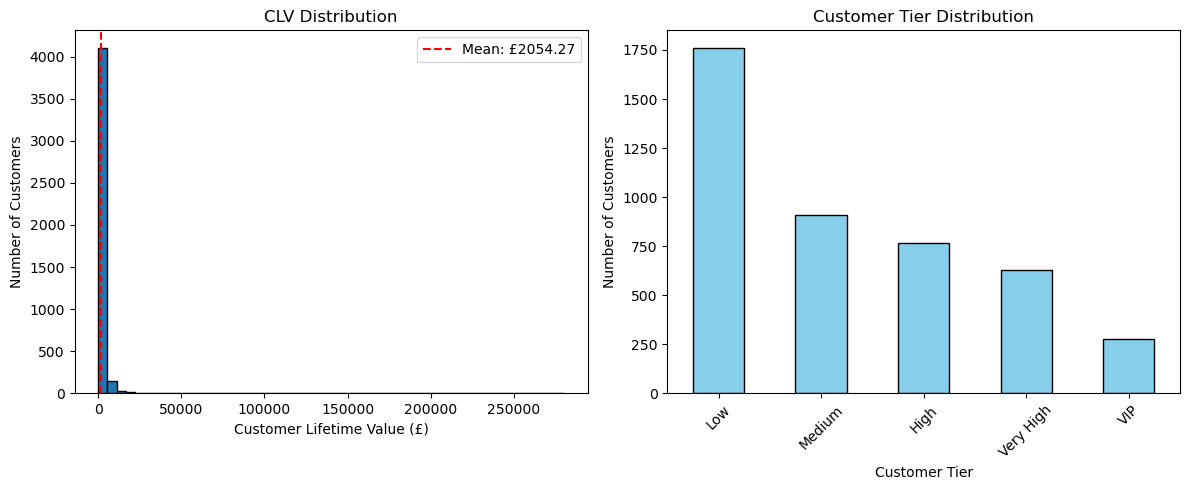

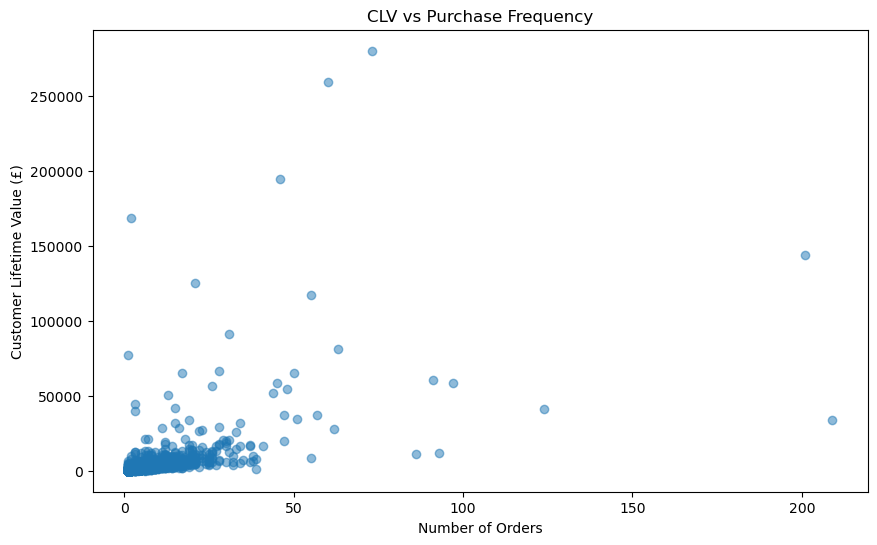

In [10]:
# CLV Distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(clv_data['historical_clv'], bins=50, edgecolor='black')
plt.xlabel('Customer Lifetime Value (£)')
plt.ylabel('Number of Customers')
plt.title('CLV Distribution')
plt.axvline(clv_data['historical_clv'].mean(), color='red', linestyle='--', label=f'Mean: £{clv_data["historical_clv"].mean():.2f}')
plt.legend()

plt.subplot(1, 2, 2)
clv_data['customer_tier'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Customer Tier')
plt.ylabel('Number of Customers')
plt.title('Customer Tier Distribution')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('clv_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# CLV vs Number of Orders
plt.figure(figsize=(10, 6))
plt.scatter(clv_data['num_orders'], clv_data['historical_clv'], alpha=0.5)
plt.xlabel('Number of Orders')
plt.ylabel('Customer Lifetime Value (£)')
plt.title('CLV vs Purchase Frequency')
plt.savefig('clv_vs_orders.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Tier summary
tier_summary = clv_data.groupby('customer_tier').agg(
    num_customers=('CustomerID', 'count'),
    avg_clv=('historical_clv', 'mean'),
    total_revenue=('historical_clv', 'sum')
).round(2)

# Export CLV data
clv_data.to_csv('customer_lifetime_value.csv', index=False)

# Top customers
top_customers.to_csv('high_value_customers.csv', index=False)

# Tier summary
tier_summary.to_csv('clv_tier_summary.csv')

print("\n✓ CLV analysis complete!")
print("Files saved: customer_lifetime_value.csv, high_value_customers.csv, clv_tier_summary.csv")


✓ CLV analysis complete!
Files saved: customer_lifetime_value.csv, high_value_customers.csv, clv_tier_summary.csv


/var/folders/yr/pn5133x93hj8g567bcn3hfw40000gn/T/ipykernel_86680/2806716231.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_summary = clv_data.groupby('customer_tier').agg(


In [12]:
#Churn Rate

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

df = pd.read_csv('cleaned_data.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Sätt referensdatum (sista datum i ditt dataset)
reference_date = df['InvoiceDate'].max()
print(f"Reference date (last date in dataset): {reference_date.date()}")


Reference date (last date in dataset): 2011-12-09


In [14]:
# Defining churn rate threshold
churn_threshold_days = 180

print(f"Churn definition: No purchase in the last {churn_threshold_days} days ({churn_threshold_days/30:.0f} months)")

Churn definition: No purchase in the last 180 days (6 months)


In [15]:
# Finding latest purchase
customer_last_purchase = df.groupby('CustomerID').agg({
    'InvoiceDate': ['min', 'max'],
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
}).reset_index()

customer_last_purchase.columns = ['CustomerID', 'first_purchase', 'last_purchase', 'num_orders', 'total_revenue']

# Calculating recency (Days since last purchase)
customer_last_purchase['recency_days'] = (reference_date - customer_last_purchase['last_purchase']).dt.days

# Customer lifespan
customer_last_purchase['lifespan_days'] = (customer_last_purchase['last_purchase'] - customer_last_purchase['first_purchase']).dt.days

print("\nCustomer recency data:")
print(customer_last_purchase.head(10))


Customer recency data:
   CustomerID      first_purchase       last_purchase  num_orders  \
0     12346.0 2011-01-18 10:01:00 2011-01-18 10:01:00           1   
1     12347.0 2010-12-07 14:57:00 2011-12-07 15:52:00           7   
2     12348.0 2010-12-16 19:09:00 2011-09-25 13:13:00           4   
3     12349.0 2011-11-21 09:51:00 2011-11-21 09:51:00           1   
4     12350.0 2011-02-02 16:01:00 2011-02-02 16:01:00           1   
5     12352.0 2011-02-16 12:33:00 2011-11-03 14:37:00           8   
6     12353.0 2011-05-19 17:47:00 2011-05-19 17:47:00           1   
7     12354.0 2011-04-21 13:11:00 2011-04-21 13:11:00           1   
8     12355.0 2011-05-09 13:49:00 2011-05-09 13:49:00           1   
9     12356.0 2011-01-18 09:50:00 2011-11-17 08:40:00           3   

   total_revenue  recency_days  lifespan_days  
0       77183.60           325              0  
1        4310.00             1            365  
2        1797.24            74            282  
3        1757.55        

In [16]:
# Churn flag
customer_last_purchase['is_churned'] = customer_last_purchase['recency_days'] > churn_threshold_days

# Add churn status categories
customer_last_purchase['churn_status'] = customer_last_purchase['recency_days'].apply(
    lambda x: 'Active' if x <= 30 else
              'At Risk' if x <= 90 else
              'Hibernating' if x <= 180 else
              'Churned'
)

# Summation
print("\nChurn Status Summary:")
print(customer_last_purchase['churn_status'].value_counts())
print(f"\nTotal customers: {len(customer_last_purchase)}")
print(f"Churned customers: {customer_last_purchase['is_churned'].sum()} ({customer_last_purchase['is_churned'].mean()*100:.1f}%)")
print(f"Active customers: {(~customer_last_purchase['is_churned']).sum()} ({(~customer_last_purchase['is_churned']).mean()*100:.1f}%)")


Churn Status Summary:
churn_status
Active         1694
At Risk        1199
Churned         858
Hibernating     587
Name: count, dtype: int64

Total customers: 4338
Churned customers: 858 (19.8%)
Active customers: 3480 (80.2%)


In [17]:
# Overall churn rate
total_customers = len(customer_last_purchase)
churned_customers = customer_last_purchase['is_churned'].sum()
churn_rate = churned_customers / total_customers

print(f"\n=== CHURN METRICS ===")
print(f"Total Customers: {total_customers}")
print(f"Churned Customers: {churned_customers}")
print(f"Overall Churn Rate: {churn_rate*100:.2f}%")
print(f"Retention Rate: {(1-churn_rate)*100:.2f}%")


=== CHURN METRICS ===
Total Customers: 4338
Churned Customers: 858
Overall Churn Rate: 19.78%
Retention Rate: 80.22%


In [18]:
# Fixa CustomerID datatyp
customer_last_purchase['CustomerID'] = customer_last_purchase['CustomerID'].astype(int)
rfm_segments = pd.read_csv('RFM_segment.csv')
rfm_segments['CustomerID'] = rfm_segments['CustomerID'].astype(int)

# Merga churn data med RFM
churn_with_rfm = customer_last_purchase.merge(
    rfm_segments[['CustomerID', 'customer_segment']], 
    on='CustomerID', 
    how='left'
)

# Churn rate per RFM segment
churn_by_segment = churn_with_rfm.groupby('customer_segment').agg({
    'CustomerID': 'count',
    'is_churned': ['sum', 'mean'],
    'total_revenue': 'sum'
}).round(3)

churn_by_segment.columns = ['num_customers', 'churned_count', 'churn_rate', 'total_revenue']
churn_by_segment['churn_rate_pct'] = churn_by_segment['churn_rate'] * 100

print("\n=== CHURN RATE BY RFM SEGMENT ===")
print(churn_by_segment.sort_values('churn_rate', ascending=False))


=== CHURN RATE BY RFM SEGMENT ===
                  num_customers  churned_count  churn_rate  total_revenue  \
customer_segment                                                            
Lost                       1299            838       0.645     818135.281   
At Risk                      56             20       0.357     120990.900   
Big Spenders                164              0       0.000     316052.400   
Champions                   357              0       0.000    4471453.470   
Loyal Customers             628              0       0.000    1696970.550   
Others                      591              0       0.000     286498.262   
Promising                  1243              0       0.000    1201307.041   

                  churn_rate_pct  
customer_segment                  
Lost                        64.5  
At Risk                     35.7  
Big Spenders                 0.0  
Champions                    0.0  
Loyal Customers              0.0  
Others                    

In [19]:
# Create value tiers
customer_last_purchase['value_tier'] = pd.qcut(
    customer_last_purchase['total_revenue'], 
    q=4, 
    labels=['Low Value', 'Medium Value', 'High Value', 'VIP']
)

# Churn rate per value tier
churn_by_value = customer_last_purchase.groupby('value_tier').agg({
    'CustomerID': 'count',
    'is_churned': ['sum', 'mean'],
    'total_revenue': ['sum', 'mean']
}).round(2)

churn_by_value.columns = ['num_customers', 'churned_count', 'churn_rate', 'total_revenue', 'avg_revenue']
churn_by_value['churn_rate_pct'] = churn_by_value['churn_rate'] * 100

print("\n=== CHURN RATE BY VALUE TIER ===")
print(churn_by_value)

# Revenue at risk from churned customers
revenue_at_risk = customer_last_purchase[customer_last_purchase['is_churned'] == True]['total_revenue'].sum()
total_revenue = customer_last_purchase['total_revenue'].sum()

print(f"\nRevenue at risk from churned customers: £{revenue_at_risk:.2f} ({revenue_at_risk/total_revenue*100:.1f}% of total)")


=== CHURN RATE BY VALUE TIER ===
              num_customers  churned_count  churn_rate  total_revenue  \
value_tier                                                              
Low Value              1085            440        0.41      194437.49   
Medium Value           1084            282        0.26      503529.45   
High Value             1084            105        0.10     1161895.31   
VIP                    1085             31        0.03     7051545.65   

              avg_revenue  churn_rate_pct  
value_tier                                 
Low Value          179.21            41.0  
Medium Value       464.51            26.0  
High Value        1071.86            10.0  
VIP               6499.12             3.0  

Revenue at risk from churned customers: £555527.18 (6.2% of total)


/var/folders/yr/pn5133x93hj8g567bcn3hfw40000gn/T/ipykernel_86680/270213200.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_value = customer_last_purchase.groupby('value_tier').agg({


In [20]:
# High-value customers that are "at risk"
at_risk_customers = customer_last_purchase[
    (customer_last_purchase['churn_status'] == 'At Risk') & 
    (customer_last_purchase['total_revenue'] > customer_last_purchase['total_revenue'].quantile(0.75))
].sort_values('total_revenue', ascending=False)

print(f"\n=== HIGH-VALUE CUSTOMERS AT RISK ===")
print(f"Number of high-value at-risk customers: {len(at_risk_customers)}")
print(f"Potential revenue at risk: £{at_risk_customers['total_revenue'].sum():.2f}")
print("\nTop 10 at-risk customers:")
print(at_risk_customers[['CustomerID', 'recency_days', 'num_orders', 'total_revenue']].head(10))


=== HIGH-VALUE CUSTOMERS AT RISK ===
Number of high-value at-risk customers: 263
Potential revenue at risk: £969426.88

Top 10 at-risk customers:
      CustomerID  recency_days  num_orders  total_revenue
2702       16029            38          63       81024.84
324        12744            51           7       21279.29
269        12678            41          12       17628.46
2324       15513            32          19       14758.22
152        12536            42           3       12601.83
459        12939            63           8       11581.80
50         12409            78           3       11072.67
3488       17107            32           6       10815.43
748        13340            44           7       10736.48
3302       16843            42          16       10196.57


In [21]:
# Group by recency ranges
customer_last_purchase['recency_bucket'] = pd.cut(
    customer_last_purchase['recency_days'],
    bins=[0, 30, 60, 90, 120, 180, 365, float('inf')],
    labels=['0-30 days', '31-60 days', '61-90 days', '91-120 days', '121-180 days', '181-365 days', '365+ days']
)

recency_analysis = customer_last_purchase.groupby('recency_bucket').agg({
    'CustomerID': 'count',
    'is_churned': 'sum',
    'total_revenue': 'sum'
}).round(2)

recency_analysis.columns = ['num_customers', 'churned_count', 'total_revenue']

print("\n=== CUSTOMERS BY RECENCY BUCKET ===")
print(recency_analysis)


=== CUSTOMERS BY RECENCY BUCKET ===
                num_customers  churned_count  total_revenue
recency_bucket                                             
0-30 days                1601              0     5156664.64
31-60 days                728              0     1033180.96
61-90 days                471              0      502011.39
91-120 days               230              0      218307.68
121-180 days              357              0      259529.22
181-365 days              800            800      535504.39
365+ days                  58             58       20022.79


/var/folders/yr/pn5133x93hj8g567bcn3hfw40000gn/T/ipykernel_86680/1470969748.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  recency_analysis = customer_last_purchase.groupby('recency_bucket').agg({


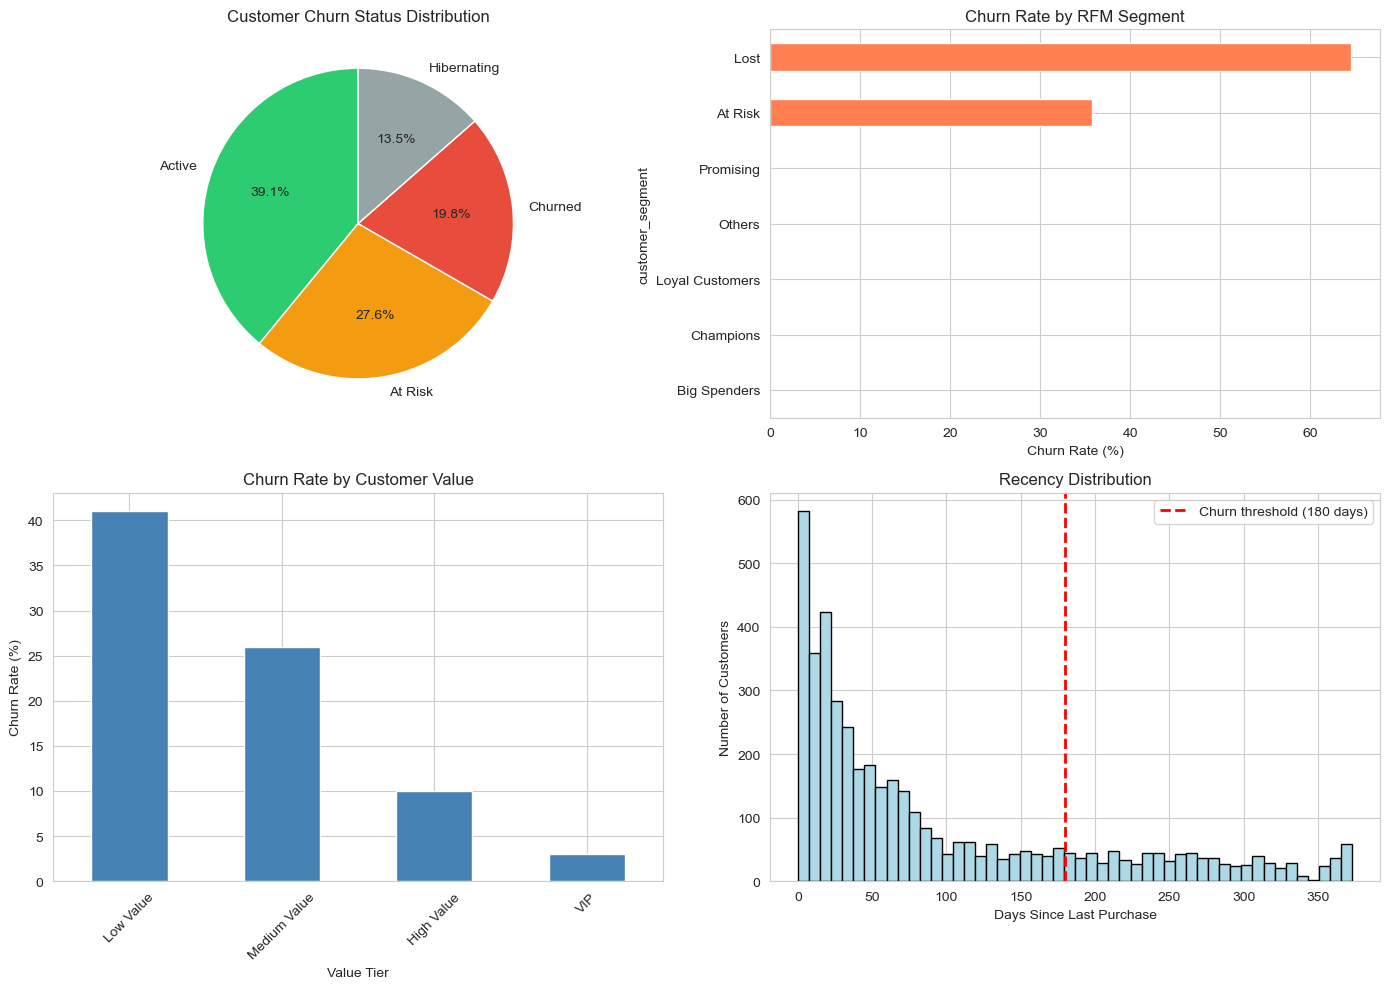

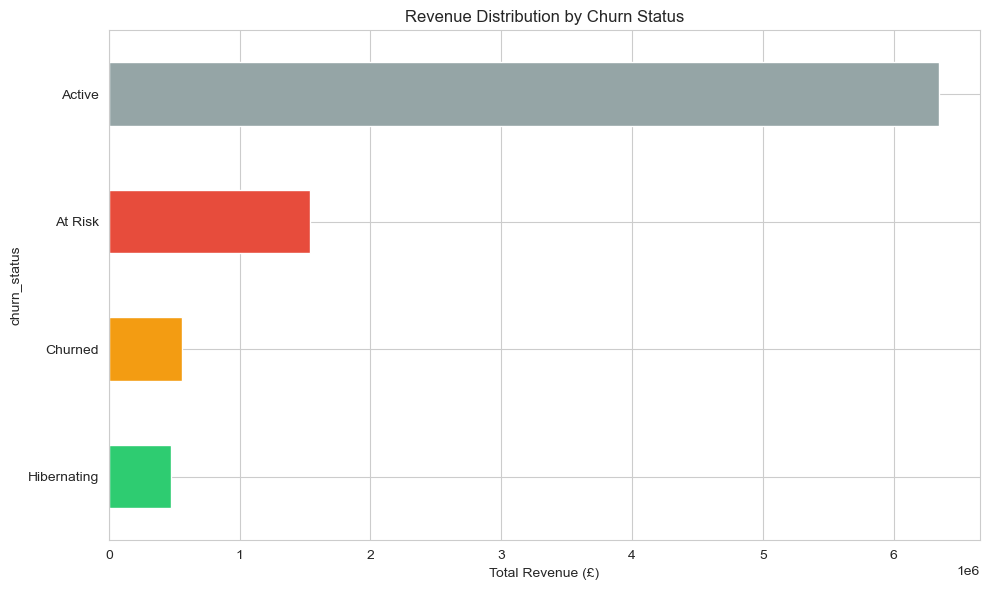

In [22]:
# Set style
sns.set_style("whitegrid")

# 1. Churn Status Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pie chart - Churn status
axes[0, 0].pie(customer_last_purchase['churn_status'].value_counts(), 
               labels=customer_last_purchase['churn_status'].value_counts().index,
               autopct='%1.1f%%', 
               startangle=90,
               colors=['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6'])
axes[0, 0].set_title('Customer Churn Status Distribution')

# Bar chart - Churn by segment
if 'customer_segment' in churn_with_rfm.columns:
    churn_by_segment['churn_rate_pct'].sort_values().plot(kind='barh', ax=axes[0, 1], color='coral')
    axes[0, 1].set_xlabel('Churn Rate (%)')
    axes[0, 1].set_title('Churn Rate by RFM Segment')

# Bar chart - Churn by value tier
churn_by_value['churn_rate_pct'].plot(kind='bar', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_xlabel('Value Tier')
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].set_title('Churn Rate by Customer Value')
axes[1, 0].tick_params(axis='x', rotation=45)

# Histogram - Recency distribution
axes[1, 1].hist(customer_last_purchase['recency_days'], bins=50, edgecolor='black', color='lightblue')
axes[1, 1].axvline(churn_threshold_days, color='red', linestyle='--', linewidth=2, label=f'Churn threshold ({churn_threshold_days} days)')
axes[1, 1].set_xlabel('Days Since Last Purchase')
axes[1, 1].set_ylabel('Number of Customers')
axes[1, 1].set_title('Recency Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Revenue at Risk visualization
fig, ax = plt.subplots(figsize=(10, 6))

status_revenue = customer_last_purchase.groupby('churn_status')['total_revenue'].sum().sort_values()
status_revenue.plot(kind='barh', ax=ax, color=['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6'])
ax.set_xlabel('Total Revenue (£)')
ax.set_title('Revenue Distribution by Churn Status')
plt.tight_layout()
plt.savefig('revenue_by_churn_status.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Exportera churn data
customer_last_purchase.to_csv('customer_churn_analysis.csv', index=False)

# At-risk customers
at_risk_customers.to_csv('high_value_at_risk_customers.csv', index=False)

# Churn by segment
churn_by_segment.to_csv('churn_by_segment.csv')

# Churn by value tier
churn_by_value.to_csv('churn_by_value_tier.csv')

recency_analysis.to_csv('recency_analysis.csv')




✓ Churn analysis complete!
Files saved:
  - customer_churn_analysis.csv
  - high_value_at_risk_customers.csv
  - churn_by_segment.csv
  - churn_by_value_tier.csv


In [24]:
print("\n" + "="*50)
print("CHURN ANALYSIS SUMMARY")
print("="*50)
print(f"Overall Churn Rate: {churn_rate*100:.1f}%")
print(f"Active Customers: {(customer_last_purchase['churn_status'] == 'Active').sum()}")
print(f"At Risk Customers: {(customer_last_purchase['churn_status'] == 'At Risk').sum()}")
print(f"Churned Customers: {churned_customers}")
print(f"\nRevenue at Risk: £{revenue_at_risk:.2f}")
print(f"High-Value At-Risk Customers: {len(at_risk_customers)}")
print("\nSegment with highest churn: " + churn_by_segment['churn_rate_pct'].idxmax())
print("="*50)


CHURN ANALYSIS SUMMARY
Overall Churn Rate: 19.8%
Active Customers: 1694
At Risk Customers: 1199
Churned Customers: 858

Revenue at Risk: £555527.18
High-Value At-Risk Customers: 263

Segment with highest churn: Lost


In [ ]:
#Basket Analysis

In [2]:
# Install mlxtend if you don't have it
# pip install mlxtend

import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('cleaned_data.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')

print(f"Loaded {len(df)} transactions")
print(f"Unique invoices: {df['InvoiceNo'].nunique()}")
print(f"Unique products: {df['StockCode'].nunique()}")

Loaded 397884 transactions
Unique invoices: 18532
Unique products: 3665


In [3]:
# Create a "basket" - group products per invoice
basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().reset_index().fillna(0).set_index('InvoiceNo')

# Convert to binary (purchased or not)
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

basket_sets = basket.map(encode_units)

print(f"\nBasket matrix shape: {basket_sets.shape}")
print(f"Number of baskets (transactions): {len(basket_sets)}")
print(f"Number of unique products: {len(basket_sets.columns)}")
print("\nFirst basket example:")
print(basket_sets.head(3))



Basket matrix shape: (18532, 3877)
Number of baskets (transactions): 18532
Number of unique products: 3877

First basket example:
Description   4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
InvoiceNo                                                                     
536365                                    0                               0   
536366                                    0                               0   
536367                                    0                               0   

Description   DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK  \
InvoiceNo                                                       
536365                        0                             0   
536366                        0                             0   
536367                        0                             0   

Description   I LOVE LONDON MINI RUCKSACK   NINE DRAWER OFFICE TIDY  \
InvoiceNo                                                             
53636

In [4]:
# Remove columns (products) that are rarely purchased to speed up analysis
# Keep only products purchased in at least 50 transactions
min_support_count = 50
product_counts = basket_sets.sum()
popular_products = product_counts[product_counts >= min_support_count].index

basket_filtered = basket_sets[popular_products]

print(f"\nFiltered to {len(basket_filtered.columns)} popular products")
print(f"From {len(basket_sets.columns)} total products")


Filtered to 1815 popular products
From 3877 total products


In [12]:
# Find frequent itemsets (products often bought together)
# min_support = how often the combination must occur (e.g. 0.01 = 1% of all transactions)
frequent_itemsets = apriori(basket_filtered, min_support=0.02, use_colnames=True)

# Sort by support
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"\nFound {len(frequent_itemsets)} frequent itemsets")
print("\nTop 20 most frequent itemsets:")
print(frequent_itemsets.head(20))

/opt/anaconda3/lib/python3.13/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(



Found 243 frequent itemsets

Top 20 most frequent itemsets:
      support                              itemsets
192  0.106357  (WHITE HANGING HEART T-LIGHT HOLDER)
154  0.091895            (REGENCY CAKESTAND 3 TIER)
81   0.086337             (JUMBO BAG RED RETROSPOT)
124  0.074412                       (PARTY BUNTING)
11   0.074196       (ASSORTED COLOUR BIRD ORNAMENT)
102  0.069501             (LUNCH BAG RED RETROSPOT)
166  0.061839   (SET OF 3 CAKE TINS PANTRY DESIGN )
139  0.059303                             (POSTAGE)
95   0.056767             (LUNCH BAG  BLACK SKULL.)
116  0.055526     (PACK OF 72 RETROSPOT CAKE CASES)
180  0.054123                      (SPOTTY BUNTING)
103  0.053313          (LUNCH BAG SPACEBOY DESIGN )
120  0.052882     (PAPER CHAIN KIT 50'S CHRISTMAS )
109  0.052180     (NATURAL SLATE HEART CHALKBOARD )
98   0.052126                 (LUNCH BAG CARS BLUE)
61   0.051856               (HEART OF WICKER SMALL)
101  0.050237             (LUNCH BAG PINK POLKADOT)
104

In [13]:
# Create association rules with metrics
# metric='lift' means we look at lift value
# min_threshold=1 means we only want rules where lift > 1 (positive association)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Add number of items in antecedents and consequents
rules['antecedent_len'] = rules['antecedents'].apply(lambda x: len(x))
rules['consequent_len'] = rules['consequents'].apply(lambda x: len(x))

print(f"\nGenerated {len(rules)} association rules")
print("\nRules columns:")
print(rules.columns.tolist())


Generated 76 association rules

Rules columns:
['antecedents', 'consequents', 'antecedent support', 'consequent support', 'support', 'confidence', 'lift', 'representativity', 'leverage', 'conviction', 'zhangs_metric', 'jaccard', 'certainty', 'kulczynski', 'antecedent_len', 'consequent_len']


In [14]:
print("\n" + "="*60)
print("UNDERSTANDING THE METRICS")
print("="*60)
print("Support: How often items appear together (frequency)")
print("  - Example: 5% support = appears in 5% of all transactions")
print("")
print("Confidence: If you buy A, how likely you buy B")
print("  - Example: 80% confidence = 80% of people who buy A also buy B")
print("")
print("Lift: How much more likely you buy B if you bought A")
print("  - Lift > 1: Positive correlation (buy together more than random)")
print("  - Lift = 1: No correlation")
print("  - Lift < 1: Negative correlation (don't buy together)")
print("="*60)


UNDERSTANDING THE METRICS
Support: How often items appear together (frequency)
  - Example: 5% support = appears in 5% of all transactions

Confidence: If you buy A, how likely you buy B
  - Example: 80% confidence = 80% of people who buy A also buy B

Lift: How much more likely you buy B if you bought A
  - Lift > 1: Positive correlation (buy together more than random)
  - Lift = 1: No correlation
  - Lift < 1: Negative correlation (don't buy together)


In [15]:
rules['lift'] = rules['lift'].astype(float)
rules['confidence'] = rules['confidence'].astype(float)
rules['support'] = rules['support'].astype(float)

rules_filtered = rules[rules['antecedent_len'] >= 1]

print("\n=== TOP 10 RULES BY LIFT ===")
top_lift = rules_filtered.nlargest(10, 'lift')[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
print(top_lift.to_string())

print("\n=== TOP 10 RULES BY CONFIDENCE ===")
top_confidence = rules_filtered.nlargest(10, 'confidence')[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
print(top_confidence.to_string())

print("\n=== TOP 10 RULES BY SUPPORT ===")
top_support = rules_filtered.nlargest(10, 'support')[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
print(top_support.to_string())


=== TOP 10 RULES BY LIFT ===
                                                            antecedents                                                          consequents   support  confidence       lift
66                                     (PINK REGENCY TEACUP AND SAUCER)  (ROSES REGENCY TEACUP AND SAUCER , GREEN REGENCY TEACUP AND SAUCER)  0.021045    0.701439  24.027846
63  (ROSES REGENCY TEACUP AND SAUCER , GREEN REGENCY TEACUP AND SAUCER)                                     (PINK REGENCY TEACUP AND SAUCER)  0.021045    0.720887  24.027846
62   (ROSES REGENCY TEACUP AND SAUCER , PINK REGENCY TEACUP AND SAUCER)                                    (GREEN REGENCY TEACUP AND SAUCER)  0.021045    0.894495  23.989564
67                                    (GREEN REGENCY TEACUP AND SAUCER)   (ROSES REGENCY TEACUP AND SAUCER , PINK REGENCY TEACUP AND SAUCER)  0.021045    0.564399  23.989564
18                                     (PINK REGENCY TEACUP AND SAUCER)                             

Total rules: 76
Filtered rules: 76
                          antecedents                         consequents  \
0           (JUMBO BAG PINK POLKADOT)           (JUMBO BAG RED RETROSPOT)   
1           (JUMBO BAG RED RETROSPOT)           (JUMBO BAG PINK POLKADOT)   
2  (ROSES REGENCY TEACUP AND SAUCER )   (GREEN REGENCY TEACUP AND SAUCER)   
3   (GREEN REGENCY TEACUP AND SAUCER)  (ROSES REGENCY TEACUP AND SAUCER )   
4        (ALARM CLOCK BAKELIKE GREEN)         (ALARM CLOCK BAKELIKE RED )   
5         (ALARM CLOCK BAKELIKE RED )        (ALARM CLOCK BAKELIKE GREEN)   
6           (LUNCH BAG PINK POLKADOT)           (LUNCH BAG RED RETROSPOT)   
7           (LUNCH BAG RED RETROSPOT)           (LUNCH BAG PINK POLKADOT)   
8           (LUNCH BAG  BLACK SKULL.)           (LUNCH BAG RED RETROSPOT)   
9           (LUNCH BAG RED RETROSPOT)           (LUNCH BAG  BLACK SKULL.)   

   antecedent support  consequent support   support  confidence       lift  \
0            0.047000            0.0863

In [17]:
# Find "actionable" rules: high confidence AND high lift
actionable_rules = rules_filtered[
    (rules_filtered['confidence'] >= 0.5) &  # At least 50% confidence
    (rules_filtered['lift'] >= 2) &           # At least 2x more likely than random
    (rules_filtered['support'] >= 0.01)       # Occurs in at least 1% of transactions
].sort_values('lift', ascending=False)

print(f"\n=== ACTIONABLE RULES (High confidence + High lift) ===")
print(f"Found {len(actionable_rules)} actionable rules")
print("\nTop 20 actionable product combinations:")
print(actionable_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))


=== ACTIONABLE RULES (High confidence + High lift) ===
Found 32 actionable rules

Top 20 actionable product combinations:
                                          antecedents  \
66                   (PINK REGENCY TEACUP AND SAUCER)   
63  (ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...   
67                  (GREEN REGENCY TEACUP AND SAUCER)   
62  (ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...   
18                   (PINK REGENCY TEACUP AND SAUCER)   
19                  (GREEN REGENCY TEACUP AND SAUCER)   
64  (PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...   
28                 (ROSES REGENCY TEACUP AND SAUCER )   
29                   (PINK REGENCY TEACUP AND SAUCER)   
2                  (ROSES REGENCY TEACUP AND SAUCER )   
3                   (GREEN REGENCY TEACUP AND SAUCER)   
39                             (DOLLY GIRL LUNCH BOX)   
38                              (SPACEBOY LUNCH BOX )   
17                (GARDENERS KNEELING PAD KEEP CALM )   
16               (GARD

In [18]:
# Function to find recommendations for a specific product
def get_recommendations(product_name, rules_df, top_n=5):
    """Find top products bought with given product"""
    # Filter rules where product is in antecedents
    product_rules = rules_df[rules_df['antecedents'].apply(lambda x: product_name in x)]
    
    if len(product_rules) == 0:
        return f"No recommendations found for '{product_name}'"
    
    # Sort by lift
    top_recommendations = product_rules.nlargest(top_n, 'lift')[['antecedents', 'consequents', 'confidence', 'lift']]
    
    return top_recommendations

# Test for a popular product (choose from your data)
# First find a popular product
popular_product = basket_filtered.sum().nlargest(1).index[0]

print(f"\n=== RECOMMENDATIONS FOR: {popular_product} ===")
recommendations = get_recommendations(popular_product, rules_filtered, top_n=10)
print(recommendations)


=== RECOMMENDATIONS FOR: WHITE HANGING HEART T-LIGHT HOLDER ===
                             antecedents                         consequents  \
22  (WHITE HANGING HEART T-LIGHT HOLDER)  (RED HANGING HEART T-LIGHT HOLDER)   

    confidence      lift  
22    0.230847  6.300533  


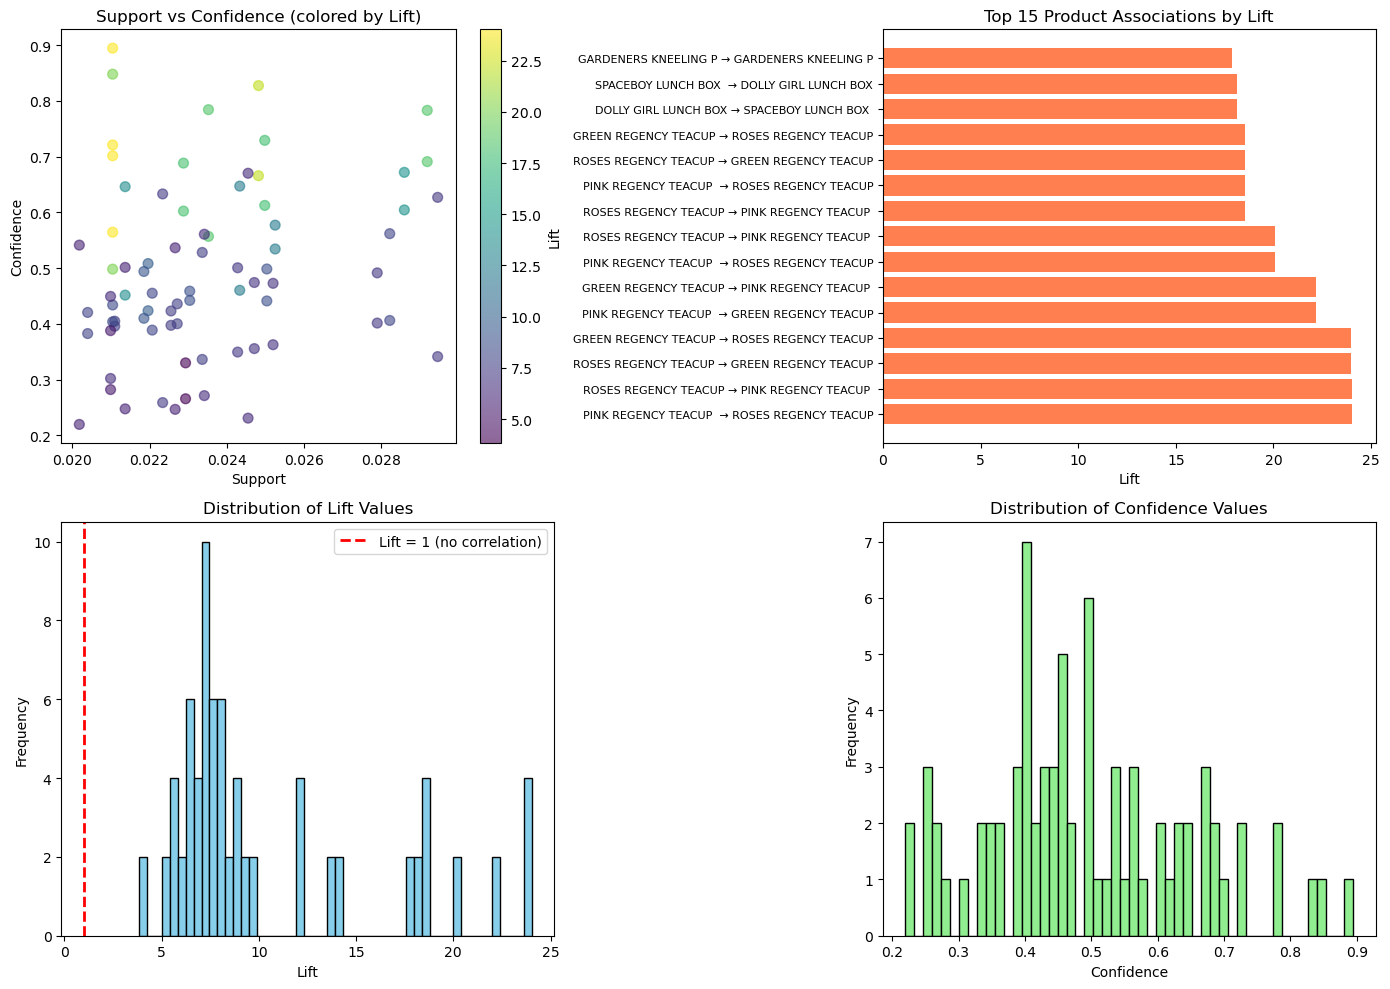

In [19]:
# 1. Support vs Confidence scatter plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter: Support vs Confidence colored by Lift
scatter = axes[0, 0].scatter(rules_filtered['support'], 
                              rules_filtered['confidence'], 
                              c=rules_filtered['lift'], 
                              cmap='viridis', 
                              alpha=0.6,
                              s=50)
axes[0, 0].set_xlabel('Support')
axes[0, 0].set_ylabel('Confidence')
axes[0, 0].set_title('Support vs Confidence (colored by Lift)')
plt.colorbar(scatter, ax=axes[0, 0], label='Lift')

# Top 15 rules by lift (bar chart)
top_15_lift = rules_filtered.nlargest(15, 'lift')
# Create labels for better readability
top_15_lift['rule_label'] = top_15_lift.apply(
    lambda x: f"{list(x['antecedents'])[0][:20]} → {list(x['consequents'])[0][:20]}", axis=1
)
axes[0, 1].barh(range(len(top_15_lift)), top_15_lift['lift'], color='coral')
axes[0, 1].set_yticks(range(len(top_15_lift)))
axes[0, 1].set_yticklabels(top_15_lift['rule_label'], fontsize=8)
axes[0, 1].set_xlabel('Lift')
axes[0, 1].set_title('Top 15 Product Associations by Lift')

# Lift distribution
axes[1, 0].hist(rules_filtered['lift'], bins=50, edgecolor='black', color='skyblue')
axes[1, 0].axvline(1, color='red', linestyle='--', linewidth=2, label='Lift = 1 (no correlation)')
axes[1, 0].set_xlabel('Lift')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Lift Values')
axes[1, 0].legend()

# Confidence distribution
axes[1, 1].hist(rules_filtered['confidence'], bins=50, edgecolor='black', color='lightgreen')
axes[1, 1].set_xlabel('Confidence')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Confidence Values')

plt.tight_layout()
plt.savefig('basket_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

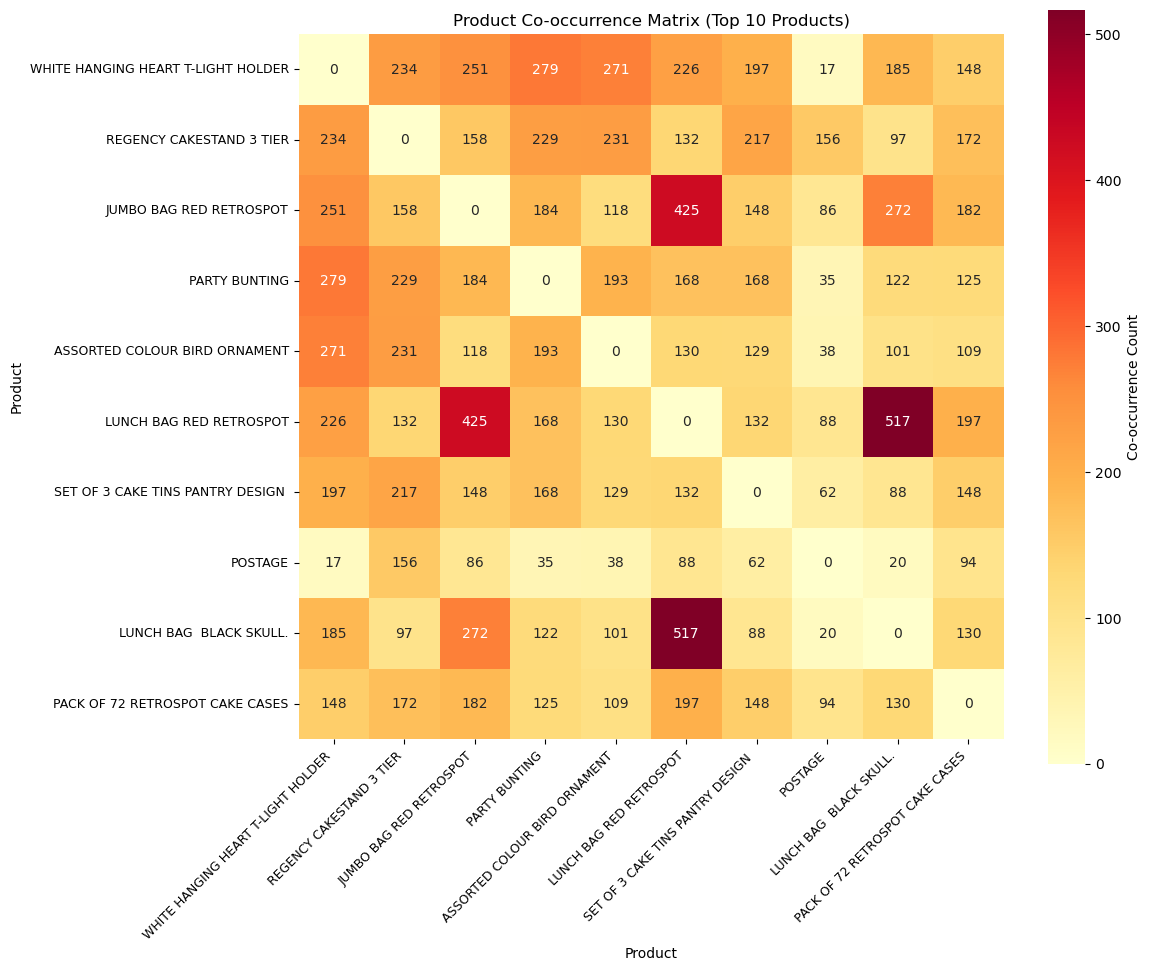

In [20]:
# Create a heatmap of top products bought together
from itertools import combinations

# Take top 10 products
top_products = basket_filtered.sum().nlargest(10).index.tolist()

# Create co-occurrence matrix
cooccurrence = pd.DataFrame(0, index=top_products, columns=top_products)

for col in basket_filtered.columns:
    if col in top_products:
        for col2 in basket_filtered.columns:
            if col2 in top_products and col != col2:
                # Count how often they're bought together
                cooccurrence.loc[col, col2] = ((basket_filtered[col] == 1) & (basket_filtered[col2] == 1)).sum()

# Visualize
plt.figure(figsize=(12, 10))
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd', square=True, cbar_kws={'label': 'Co-occurrence Count'})
plt.title('Product Co-occurrence Matrix (Top 10 Products)')
plt.xlabel('Product')
plt.ylabel('Product')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('product_cooccurrence_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Export results
frequent_itemsets.to_csv('frequent_itemsets.csv', index=False)
rules_filtered.to_csv('association_rules.csv', index=False)
actionable_rules.to_csv('actionable_product_combinations.csv', index=False)

# Create a human-readable version
rules_export = rules_filtered[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(list(x)))
rules_export.to_csv('association_rules_readable.csv', index=False)


In [22]:
print("\n" + "="*60)
print("BASKET ANALYSIS SUMMARY")
print("="*60)
print(f"Total Association Rules Found: {len(rules_filtered)}")
print(f"Actionable Rules (high confidence + lift): {len(actionable_rules)}")
print(f"\nAverage Lift: {rules_filtered['lift'].mean():.2f}")
print(f"Average Confidence: {rules_filtered['confidence'].mean():.2%}")
print(f"Average Support: {rules_filtered['support'].mean():.2%}")

print("\n--- TOP 3 STRONGEST ASSOCIATIONS ---")
for idx, row in rules_filtered.nlargest(3, 'lift').iterrows():
    ant = ', '.join(list(row['antecedents']))
    cons = ', '.join(list(row['consequents']))
    print(f"\nIf customer buys: {ant}")
    print(f"They also buy: {cons}")
    print(f"Confidence: {row['confidence']:.1%} | Lift: {row['lift']:.2f}x")

print("="*60)


BASKET ANALYSIS SUMMARY
Total Association Rules Found: 76
Actionable Rules (high confidence + lift): 32

Average Lift: 10.61
Average Confidence: 49.37%
Average Support: 2.35%

--- TOP 3 STRONGEST ASSOCIATIONS ---

If customer buys: PINK REGENCY TEACUP AND SAUCER
They also buy: ROSES REGENCY TEACUP AND SAUCER , GREEN REGENCY TEACUP AND SAUCER
Confidence: 70.1% | Lift: 24.03x

If customer buys: ROSES REGENCY TEACUP AND SAUCER , GREEN REGENCY TEACUP AND SAUCER
They also buy: PINK REGENCY TEACUP AND SAUCER
Confidence: 72.1% | Lift: 24.03x

If customer buys: ROSES REGENCY TEACUP AND SAUCER , PINK REGENCY TEACUP AND SAUCER
They also buy: GREEN REGENCY TEACUP AND SAUCER
Confidence: 89.4% | Lift: 23.99x
